# CALLING LIBRARY

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# LOAD DATA

In [2]:
df1 = pd.read_csv("d1.csv")


# INFO FOR DATA

In [3]:
df1.sample(3)

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
89,25/07/2025 20:37:52,post-graduate,2,2,Noisy,Analyze the situation and handle it with intel...,No,4,4
44,24/07/2025 22:34:34,undergraduate,4,2,Noisy,Analyze the situation and handle it with intel...,No,2,2
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4


In [4]:
# DISPLAY NAN VALUES

# cleaning data

In [5]:
df1.isna().sum()

Timestamp                                                              0
Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      1
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64

In [6]:
# DROP ROW INCLUDE NAN

In [7]:
df1=df1.dropna()

In [8]:
# DISPLAY COLUMN NAMES

In [9]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')

In [10]:
# DISPLAY DATA TYPE FOR EVERY COLUMN

In [11]:
df1.dtypes

Timestamp                                                              object
Your Academic Stage                                                    object
Peer pressure                                                           int64
Academic pressure from your home                                        int64
Study Environment                                                      object
What coping strategy you use as a student?                             object
Do you have any bad habits like smoking, drinking on a daily basis?    object
What would you rate the academic  competition in your student life      int64
Rate your academic stress index                                         int64
dtype: object

In [12]:
# DISPLAY SIMPLE Description FOR DATA

In [13]:
df1.describe().round()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index
count,139.0,139.0,139.0,139.0
mean,3.0,3.0,3.0,4.0
std,1.0,1.0,1.0,1.0
min,1.0,1.0,1.0,1.0
25%,2.0,2.0,3.0,3.0
50%,3.0,3.0,4.0,4.0
75%,4.0,4.0,4.0,4.0
max,5.0,5.0,5.0,5.0


In [14]:
# DISPLAY GENERAL INFORMATION 

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            139 non-null    object
 1   Your Academic Stage                                                  139 non-null    object
 2   Peer pressure                                                        139 non-null    int64 
 3   Academic pressure from your home                                     139 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           139 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  139 non-null    object
 7   What would you rate the

In [16]:
# Identifying duplicate items

In [17]:
df1["Your Academic Stage"].unique()

array(['undergraduate', 'high school', 'post-graduate'], dtype=object)

In [18]:
df1["Peer pressure"].unique()

array([4, 3, 1, 5, 2])

In [19]:
# Converting numbers into words that express meaning

In [20]:
peer_pressure_map = {
    1: 'Very Low',
    2: 'Low',
    3: 'Moderate',
    4: 'High',
    5: 'Very High'
}

df1['Peer pressure'] = df1['Peer pressure'].map(peer_pressure_map)

In [21]:
df1["Peer pressure"].unique()

array(['High', 'Moderate', 'Very Low', 'Very High', 'Low'], dtype=object)

In [22]:
df1["Academic pressure from your home"].unique()

array([5, 4, 1, 2, 3])

In [23]:
academic_map = {
    1: 'No Pressure',
    2: 'Slight Pressure',
    3: 'Moderate Pressure',
    4: 'Strong Pressure',
    5: 'Extreme Pressure'
}

# تطبيق التغيير
df1['Academic pressure from your home'] = df1['Academic pressure from your home'].map(academic_map)

In [24]:
df1["Academic pressure from your home"].unique()

array(['Extreme Pressure', 'Strong Pressure', 'No Pressure',
       'Slight Pressure', 'Moderate Pressure'], dtype=object)

In [25]:
df1["Study Environment"].unique()

array(['Noisy', 'Peaceful', 'disrupted'], dtype=object)

In [26]:
df1["What coping strategy you use as a student?"].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

In [27]:
coping_map = {
    'Analyze the situation and handle it with intellect': 'Problem Solving',
    'Social support (friends, family)': 'Social Support',
    'Emotional breakdown (crying a lot)': 'Emotional Release'
}

df1['What coping strategy you use as a student?'] = df1['What coping strategy you use as a student?'].map(coping_map)

In [28]:
# The column name was changed due to its length.

In [29]:
df1.rename(columns={'What coping strategy you use as a student?': 'Coping_Mechanism'}, inplace=True)

In [30]:
df1.sample()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,Coping_Mechanism,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
131,12/08/2025 15:01:20,high school,High,Strong Pressure,Peaceful,Problem Solving,No,3,4


In [31]:
df1.rename(columns={'Do you have any bad habits like smoking, drinking on a daily basis?': 'Lifestyle_Habits'}, inplace=True)

In [32]:
df1["Lifestyle_Habits"].unique()

array(['No', 'prefer not to say', 'Yes'], dtype=object)

In [33]:
# Substitution for clarification

In [34]:
df1["Lifestyle_Habits"]=df1["Lifestyle_Habits"].replace(["prefer not to say"],"Decline",regex= True)

In [35]:
df1["Lifestyle_Habits"].unique()

array(['No', 'Decline', 'Yes'], dtype=object)

In [36]:
df1.rename(columns={"What would you rate the academic  competition in your student life": 'Academic Competition'}, inplace=True)


In [37]:

competition_map = {
    1: 'Negligible',
    2: 'Low',
    3: 'Moderate',
    4: 'High',
    5: 'Fierce'
}

df1['Academic Competition'] = df1['Academic Competition'].map(competition_map)

In [38]:
df1['Academic Competition'].unique()

array(['Moderate', 'Low', 'High', 'Fierce', 'Negligible'], dtype=object)

In [39]:
df1.rename(columns={'Rate your academic stress index ': 'Academic_Stress_Level'}, inplace=True)

stress_map = {
    1: 'Minimal',
    2: 'Mild',
    3: 'Moderate',
    4: 'Severe',
    5: 'Overwhelming'
}

df1['Academic_Stress_Level'] = df1['Academic_Stress_Level'].map(stress_map)

In [40]:
df1['Academic_Stress_Level'].unique()

array(['Overwhelming', 'Moderate', 'Severe', 'Mild', 'Minimal'],
      dtype=object)

In [41]:
# Breaking down the column of history into its primary components

In [42]:
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], format='%d/%m/%Y %H:%M:%S', utc=True)
df1['month'] = df1['Timestamp'].dt.month
df1['year'] = df1['Timestamp'].dt.year
df1['day_name'] = df1['Timestamp'].dt.day_name()

In [43]:
df1['day'] = df1['Timestamp'].dt.day

In [44]:
df1["day"]=df1["day"].astype(object)

In [45]:
import calendar


In [46]:
month_map = {i: calendar.month_name[i] for i in range(1, 13)}
df1['Month_Name'] = df1['month'].map(month_map)

In [47]:
df1=df1.drop(["month"],axis=1)

In [48]:
df1.sample()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,Coping_Mechanism,Lifestyle_Habits,Academic Competition,Academic_Stress_Level,year,day_name,day,Month_Name
28,2025-07-24 22:19:51+00:00,undergraduate,Very High,No Pressure,disrupted,Social Support,No,High,Overwhelming,2025,Thursday,24,July


In [49]:
df1["year"]=df1["year"].astype("object")

In [50]:
df1.rename(columns = {"Academic pressure from your home":"Academic pressure home"},inplace =True)



In [51]:
df1

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure home,Study Environment,Coping_Mechanism,Lifestyle_Habits,Academic Competition,Academic_Stress_Level,year,day_name,day,Month_Name
0,2025-07-24 22:05:39+00:00,undergraduate,High,Extreme Pressure,Noisy,Problem Solving,No,Moderate,Overwhelming,2025,Thursday,24,July
1,2025-07-24 22:05:52+00:00,undergraduate,Moderate,Strong Pressure,Peaceful,Problem Solving,No,Moderate,Moderate,2025,Thursday,24,July
2,2025-07-24 22:06:39+00:00,undergraduate,Very Low,No Pressure,Peaceful,Social Support,No,Low,Severe,2025,Thursday,24,July
3,2025-07-24 22:06:45+00:00,undergraduate,Moderate,Slight Pressure,Peaceful,Problem Solving,No,High,Moderate,2025,Thursday,24,July
4,2025-07-24 22:08:06+00:00,undergraduate,Moderate,Moderate Pressure,Peaceful,Problem Solving,No,High,Overwhelming,2025,Thursday,24,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,2025-08-17 13:02:04+00:00,undergraduate,Moderate,Slight Pressure,Peaceful,Problem Solving,No,Moderate,Severe,2025,Sunday,17,August
136,2025-08-18 14:36:00+00:00,undergraduate,High,Slight Pressure,disrupted,Problem Solving,No,Moderate,Moderate,2025,Monday,18,August
137,2025-08-18 17:13:52+00:00,undergraduate,Moderate,Moderate Pressure,Peaceful,Problem Solving,No,Low,Severe,2025,Monday,18,August
138,2025-08-18 19:08:52+00:00,undergraduate,High,Extreme Pressure,disrupted,Social Support,No,Fierce,Overwhelming,2025,Monday,18,August


# export new data

In [52]:
# df1.to_csv("D:/projects/New folder/data/Edit_data/Academic_pressure.csv ")

# analysis

###  What is the numerical distribution of students in each "Your Academic Stage"?

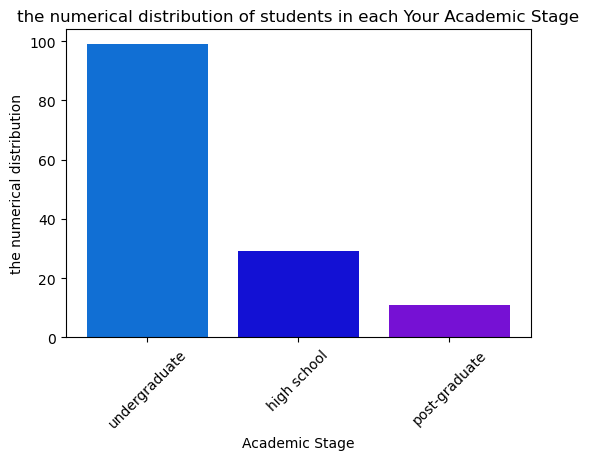

In [53]:
g = df1.groupby("Your Academic Stage")["Your Academic Stage"].count().sort_values(ascending=False)


plt.figure(figsize=(6,4))
plt.bar(g.index,g.values,color=['#116FD4', '#1311D4', '#7611D4'])
plt.title("the numerical distribution of students in each Your Academic Stage")
plt.xlabel("Academic Stage")
plt.ylabel("the numerical distribution")
plt.xticks(rotation=45)
plt.show()

### What is the percentage of each "Academic Stress" (Academic_Stress_Level) level in the sample?

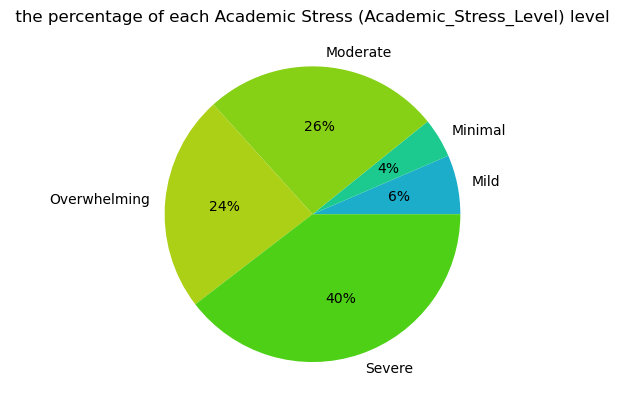

In [54]:
j = df1.groupby("Academic_Stress_Level")["Academic_Stress_Level"].count()
plt.pie(
    j.values,
    labels= j.index,
    labeldistance=1.1,
    radius=1,
    colors=["#1CADCA","#1CCA90","#86D016","#ABD016","#4ED016"],
    rotatelabels= False,
    autopct= "%1.0f%%"

)
plt.title(" the percentage of each Academic Stress (Academic_Stress_Level) level ")
plt.show()

### What is the most common "coping mechanism" among all students?

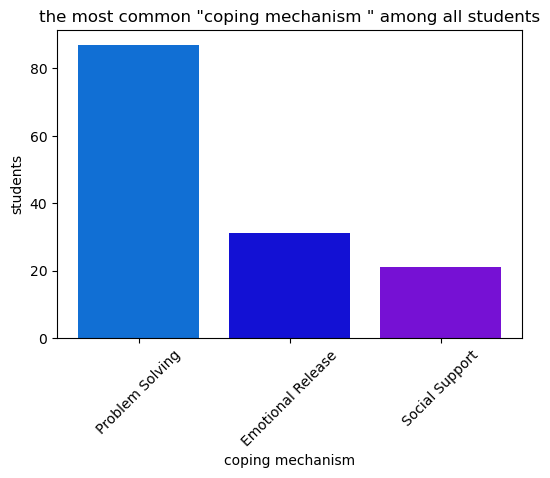

In [55]:
k = df1.groupby("Coping_Mechanism")["Coping_Mechanism"].count().sort_values(ascending=False)


plt.figure(figsize=(6,4))
plt.bar(k.index,k.values,color=['#116FD4', '#1311D4', '#7611D4'])
plt.title("the most common \"coping mechanism \" among all students")
plt.xlabel("coping mechanism")
plt.ylabel("students")
plt.xticks(rotation=45)
plt.show()

### Does Academic Stress Level increase with increased Academic pressure home?

In [56]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [57]:
from scipy.stats import chi2_contingency

# Let's assume we want to study the relationship between the study environment and Academic pressure home
contingency_table_one = pd.crosstab(df1['Study Environment'], df1['Academic pressure home'],normalize='index')*100
print(contingency_table_one)

Academic pressure home  Extreme Pressure  Moderate Pressure  No Pressure  \
Study Environment                                                          
Noisy                          25.000000          25.000000    21.875000   
Peaceful                       14.492754          36.231884     8.695652   
disrupted                      23.684211          28.947368    10.526316   

Academic pressure home  Slight Pressure  Strong Pressure  
Study Environment                                         
Noisy                          9.375000        18.750000  
Peaceful                      24.637681        15.942029  
disrupted                     10.526316        26.315789  


In [72]:
#  Chi-Square
chi1, p1, dof1, expected1 = chi2_contingency(contingency_table_one)

print(f"Chi-Square Statistic: {chi1}")
print(f"P-value: {p1}")
print(f"{expected1}")

Chi-Square Statistic: 25.276576390718454
P-value: 0.0013953241259972685
[[21.05898805 30.05975083 13.69898932 14.84633232 20.33593949]
 [21.05898805 30.05975083 13.69898932 14.84633232 20.33593949]
 [21.05898805 30.05975083 13.69898932 14.84633232 20.33593949]]


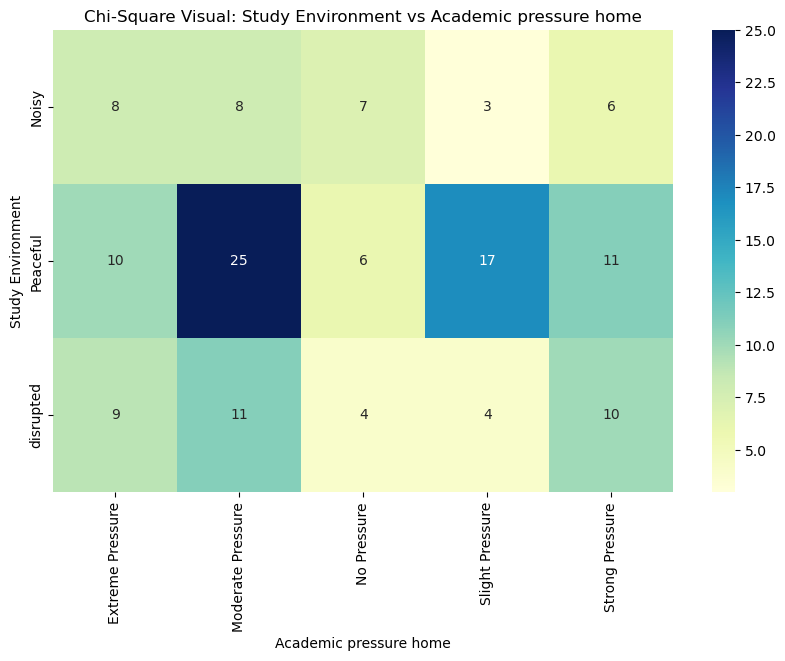

In [59]:
# 1. Contingency Table
ct1 = pd.crosstab(df1['Study Environment'], df1['Academic pressure home']) 

# 2. (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(ct1, annot=True, cmap='YlGnBu', fmt='d') 

plt.title('Chi-Square Visual: Study Environment vs Academic pressure home')
plt.xlabel('Academic pressure home')
plt.ylabel('Study Environment')
plt.show()

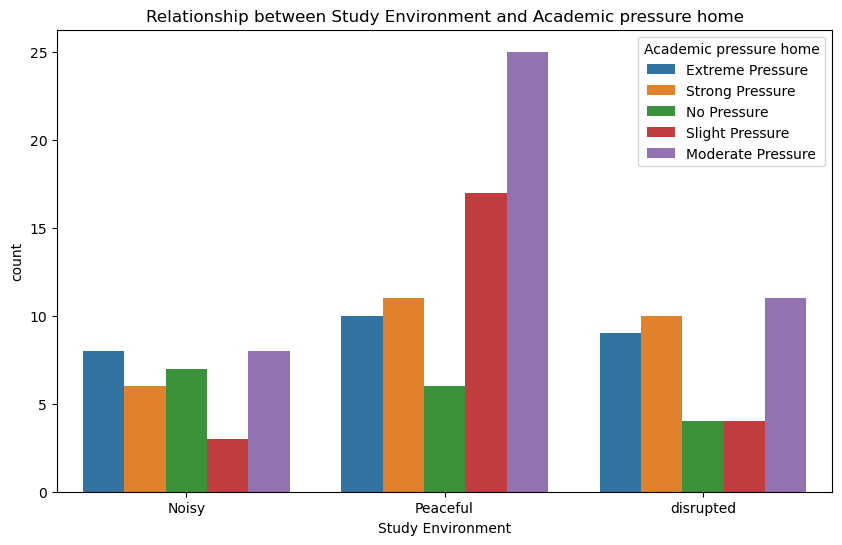

In [120]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Study Environment', hue='Academic pressure home')
plt.title('Relationship between Study Environment and Academic pressure home')
plt.show()

### What is the relationship between the "study environment" and stress levels? Does a calm environment actually mean less stress?

In [61]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [62]:

# Let's assume we want to study the relationship between the study environment and stress levels.
contingency_table_two = pd.crosstab(df1['Study Environment'], df1['Academic_Stress_Level'],normalize='index')*100
print(contingency_table_two)

Academic_Stress_Level      Mild   Minimal   Moderate  Overwhelming     Severe
Study Environment                                                            
Noisy                  6.250000  3.125000  25.000000     31.250000  34.375000
Peaceful               8.695652  5.797101  31.884058     15.942029  37.681159
disrupted              2.631579  2.631579  15.789474     31.578947  47.368421


In [63]:
# Chi-Square
chi2, p2, dof2, expected2 = chi2_contingency(contingency_table_two)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p2}")

Chi-Square Statistic: 18.438776696693054
P-value: 0.01816703201913433


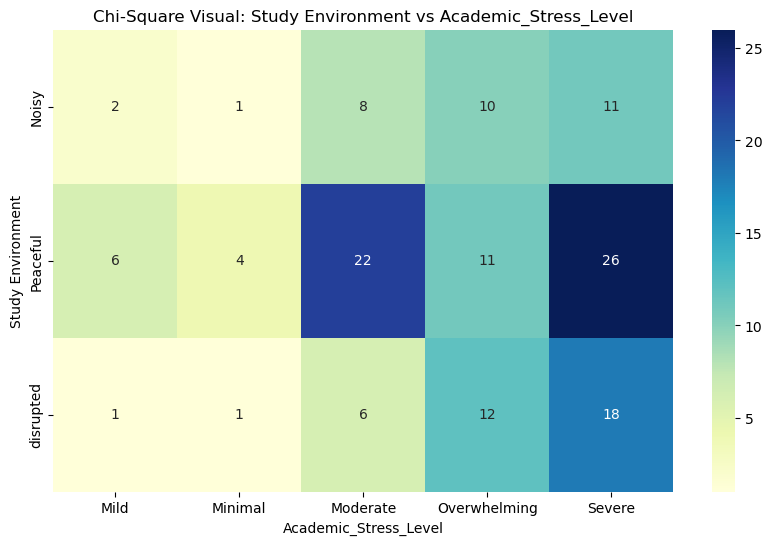

In [64]:
# 1. (Contingency Table)
ct2 = pd.crosstab(df1['Study Environment'], df1['Academic_Stress_Level']) 

# 2. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(ct2, annot=True, cmap='YlGnBu', fmt='d') 

plt.title('Chi-Square Visual: Study Environment vs Academic_Stress_Level')
plt.xlabel('Academic_Stress_Level')
plt.ylabel('Study Environment')
plt.show()

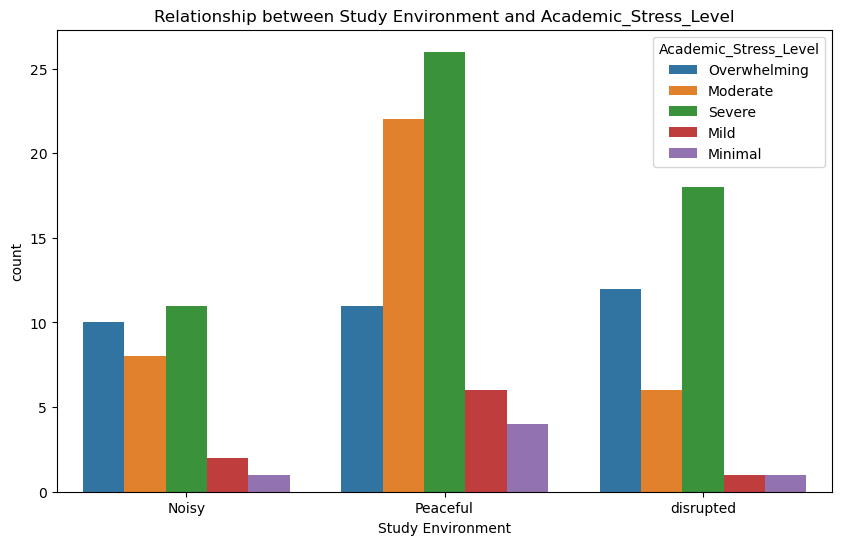

In [65]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Study Environment', hue='Academic_Stress_Level')
plt.title('Relationship between Study Environment and Academic_Stress_Level')
plt.show()

### Is there a relationship between "academic competition" and the emergence of certain "lifestyle habits"?

In [66]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [67]:

# Let's assume we want to study the relationship between the study environment and Lifestyle_Habits.
contingency_table_three = pd.crosstab(df1['Study Environment'], df1['Lifestyle_Habits'],normalize='index')*100
print(contingency_table_three)

Lifestyle_Habits    Decline         No        Yes
Study Environment                                
Noisy              3.125000  87.500000   9.375000
Peaceful           5.797101  91.304348   2.898551
disrupted          5.263158  81.578947  13.157895


In [68]:
# Chi-Square
chi3, p3, dof3, expected3 = chi2_contingency(contingency_table_three)

print(f"Chi-Square Statistic: {chi3}")
print(f"P-value: {p3}")

Chi-Square Statistic: 7.749959724904954
P-value: 0.10117901666956257


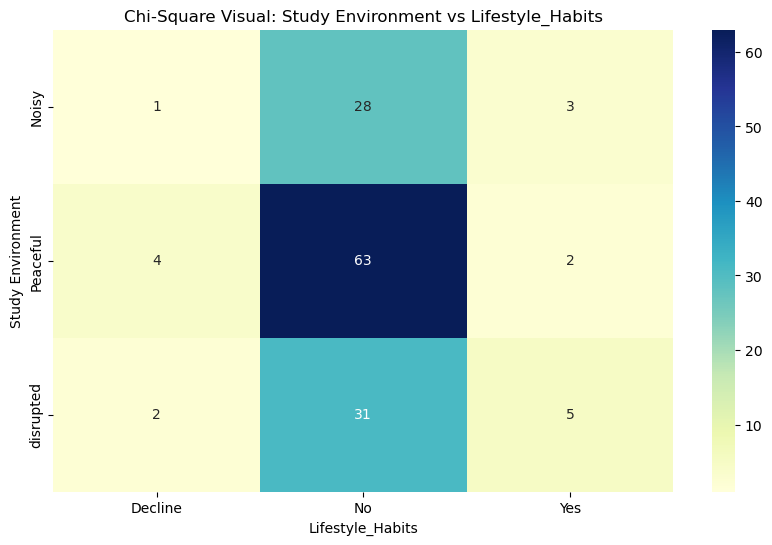

In [69]:
# 1. (Contingency Table)
ct3 = pd.crosstab(df1['Study Environment'], df1['Lifestyle_Habits']) 

# 2. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(ct3, annot=True, cmap='YlGnBu', fmt='d') 

plt.title('Chi-Square Visual: Study Environment vs Lifestyle_Habits')
plt.xlabel('Lifestyle_Habits')
plt.ylabel('Study Environment')
plt.show()

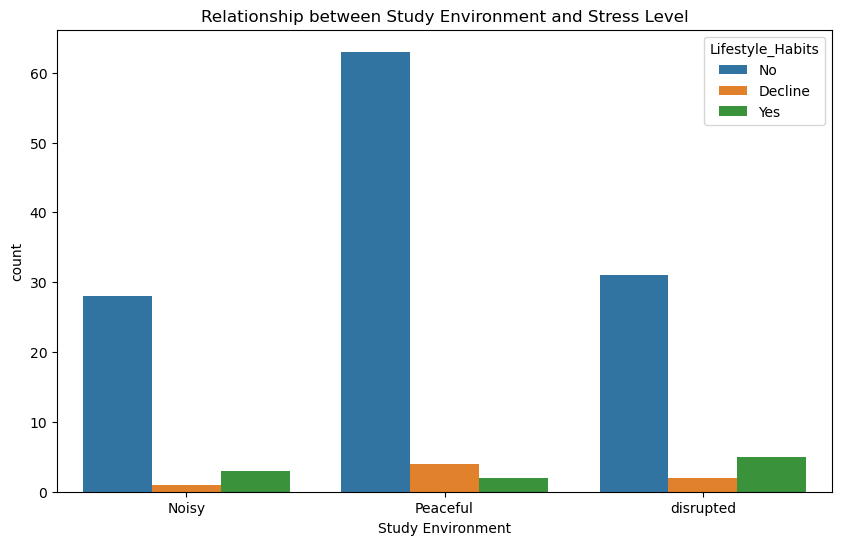

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Study Environment', hue='Lifestyle_Habits')
plt.title('Relationship between Study Environment and Lifestyle_Habits')
plt.show()

### How do coping mechanisms differ between high school students and university students?"

In [73]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [81]:
contingency_table_4 = pd.crosstab(df1["Your Academic Stage"],df1["Coping_Mechanism"],normalize ="index")*100
print(contingency_table_4)

Coping_Mechanism     Emotional Release  Problem Solving  Social Support
Your Academic Stage                                                    
high school                  37.931034        51.724138       10.344828
post-graduate                 9.090909        63.636364       27.272727
undergraduate                19.191919        65.656566       15.151515


In [100]:
chi4 , p4 , dof4 , expected4 = chi2_contingency(contingency_table_4)
print(f"Chi-Square Statistic: {chi4}")
print(f"P-value: {p4}")

Chi-Square Statistic: 273.1294809703369
P-value: 9.084476463079819e-49


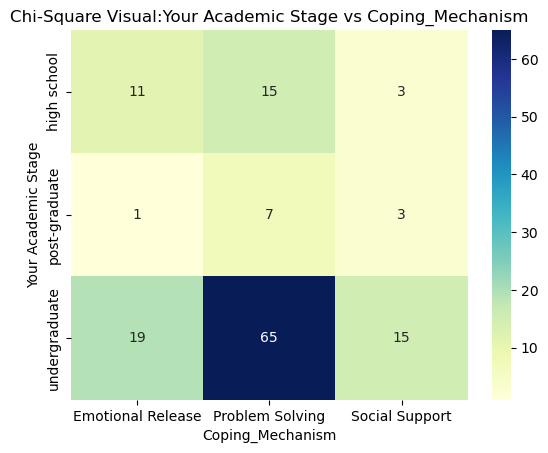

In [102]:
ct4 =  pd.crosstab(df1["Your Academic Stage"],df1["Coping_Mechanism"])

sns.heatmap(ct4,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Chi-Square Visual:Your Academic Stage vs Coping_Mechanism')
plt.xlabel('Coping_Mechanism')
plt.ylabel('Your Academic Stage')

plt.show()

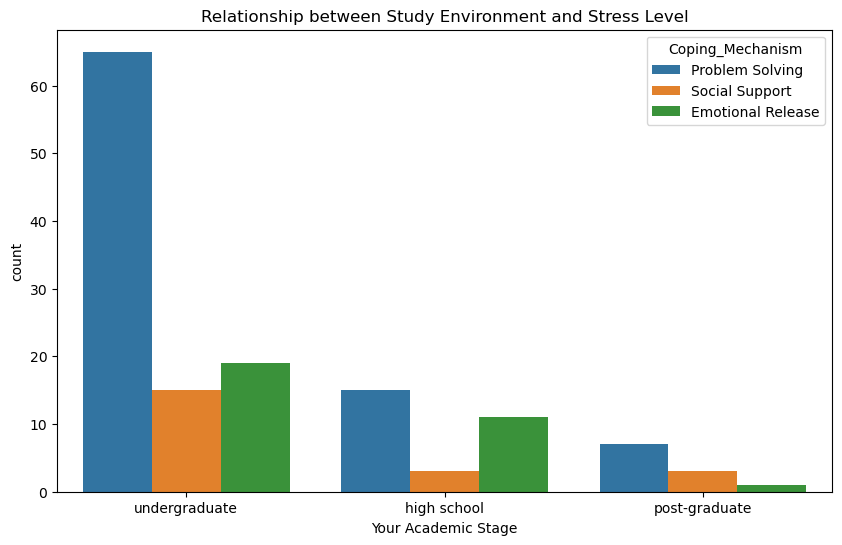

In [103]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Your Academic Stage', hue='Coping_Mechanism')
plt.title('Relationship between Your Academic Stage and Coping_Mechanism')
plt.show()

### Do students facing high peer pressure experience overwhelming stress levels more than others?"

In [104]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [105]:
contingency_table_5 = pd.crosstab(df1["Peer pressure"],df1["Academic_Stress_Level"],normalize ="index")*100
print(contingency_table_5)

Academic_Stress_Level       Mild    Minimal   Moderate  Overwhelming  \
Peer pressure                                                          
High                    3.125000   3.125000  12.500000     34.375000   
Low                    20.833333   4.166667  29.166667     12.500000   
Moderate                3.508772   0.000000  33.333333     15.789474   
Very High               0.000000   0.000000   7.692308     69.230769   
Very Low                7.692308  30.769231  38.461538      7.692308   

Academic_Stress_Level     Severe  
Peer pressure                     
High                   46.875000  
Low                    33.333333  
Moderate               47.368421  
Very High              23.076923  
Very Low               15.384615  


In [106]:
chi5 , p5 , dof5 , expected5 = chi2_contingency(contingency_table_5)
print(f"Chi-Square Statistic: {chi5}")
print(f"P-value: {p5}")

Chi-Square Statistic: 273.1294809703369
P-value: 9.084476463079819e-49


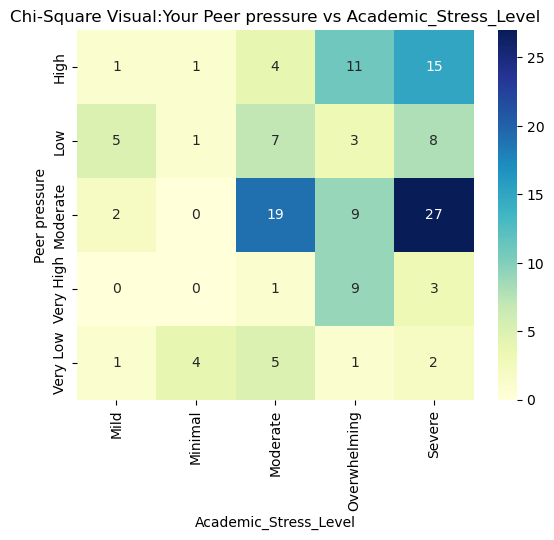

In [110]:
ct5 =  pd.crosstab(df1["Peer pressure"],df1["Academic_Stress_Level"])

sns.heatmap(ct5,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Chi-Square Visual:  Peer pressure vs Academic_Stress_Level')
plt.xlabel('Academic_Stress_Level')
plt.ylabel('Peer pressure')

plt.show()

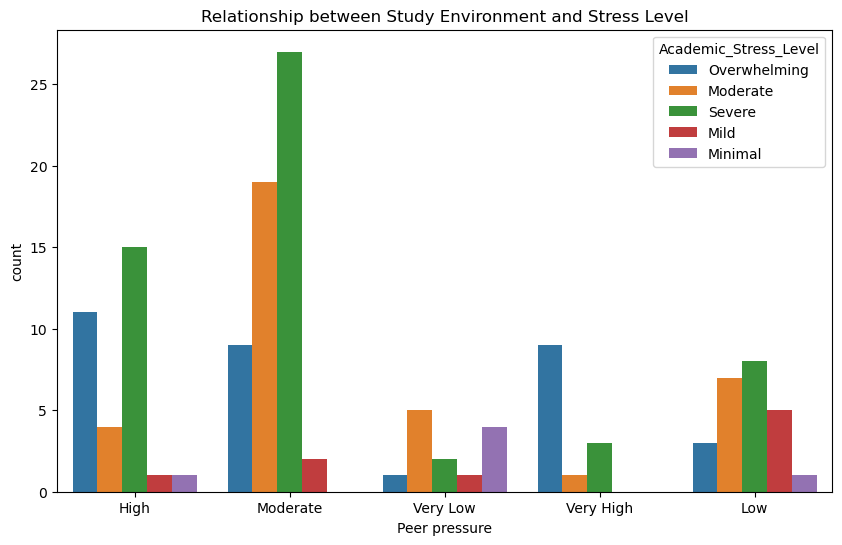

In [111]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Peer pressure', hue='Academic_Stress_Level')
plt.title('Relationship between Peer pressure and Academic_Stress_Level')
plt.show()

### "Which academic level records the highest levels of academic competition?"

In [112]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

In [115]:
contingency_table_6 = pd.crosstab(df1["Your Academic Stage"],df1["Academic Competition"],normalize ="index")*100
print(contingency_table_6)

Academic Competition     Fierce       High        Low   Moderate  Negligible
Your Academic Stage                                                         
high school           13.793103  31.034483   6.896552  44.827586    3.448276
post-graduate         18.181818  36.363636  18.181818  18.181818    9.090909
undergraduate         14.141414  43.434343  13.131313  25.252525    4.040404


In [116]:
chi6 , p6 , dof6 , expected6 = chi2_contingency(contingency_table_6)
print(f"Chi-Square Statistic: {chi6}")
print(f"P-value: {p6}")

Chi-Square Statistic: 24.319024961898315
P-value: 0.002025781747152824


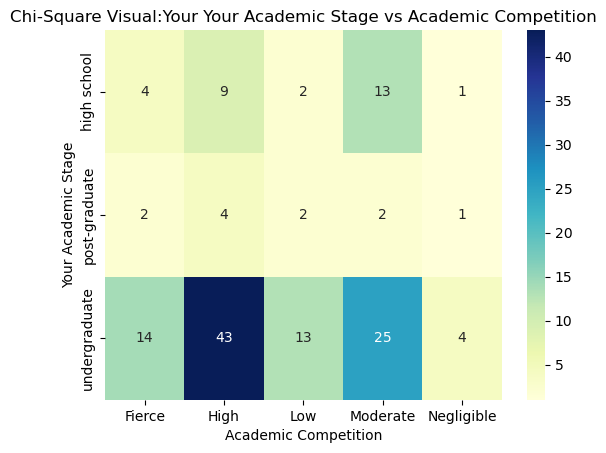

In [119]:
ct6 =  pd.crosstab(df1["Your Academic Stage"],df1["Academic Competition"])

sns.heatmap(ct6,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Chi-Square Visual: Your Academic Stage vs Academic Competition')
plt.xlabel('Academic Competition')
plt.ylabel('Your Academic Stage')

plt.show()

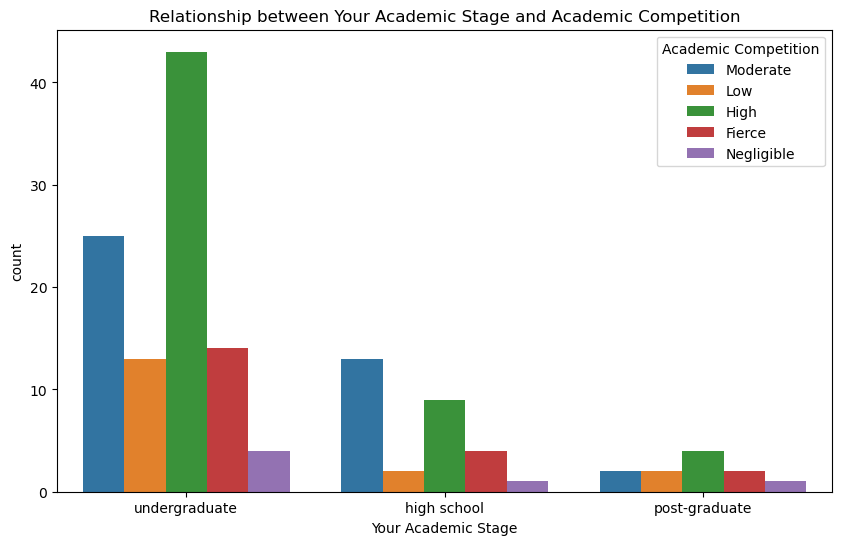

In [118]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Your Academic Stage', hue='Academic Competition')
plt.title('Relationship between Your Academic Stage and Academic Competition')
plt.show()

In [121]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

### "Are there specific days of the week when students tend to report higher stress levels?"

In [124]:
contingency_table_7 = pd.crosstab(df1["Academic_Stress_Level"],df1["day_name"],normalize ="index")*100
print(contingency_table_7)

day_name                  Friday    Monday   Saturday    Sunday   Thursday  \
Academic_Stress_Level                                                        
Mild                    0.000000  0.000000  11.111111  0.000000  77.777778   
Minimal                50.000000  0.000000  33.333333  0.000000  16.666667   
Moderate               22.222222  5.555556  19.444444  0.000000  52.777778   
Overwhelming           18.181818  6.060606  21.212121  3.030303  39.393939   
Severe                 18.181818  5.454545  14.545455  3.636364  49.090909   

day_name                Tuesday  Wednesday  
Academic_Stress_Level                       
Mild                   0.000000  11.111111  
Minimal                0.000000   0.000000  
Moderate               0.000000   0.000000  
Overwhelming           9.090909   3.030303  
Severe                 7.272727   1.818182  


In [ ]:
chi7 , p7 , dof7 , expected7 = chi2_contingency(contingency_table_7)
print(f"Chi-Square Statistic: {chi7}")
print(f"P-value: {p7}")

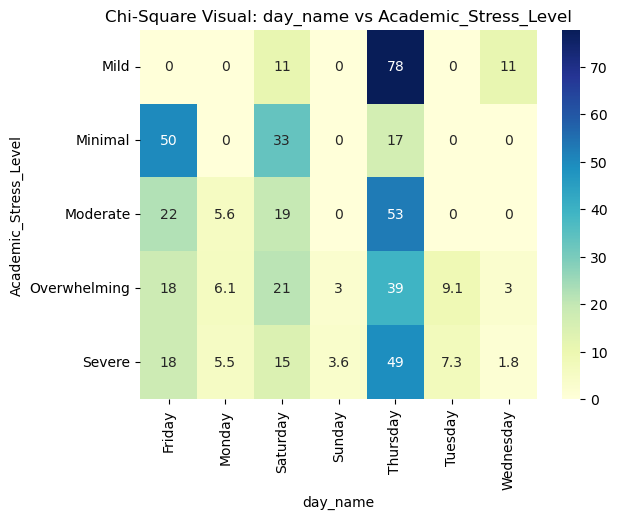

In [126]:
ct7 = pd.crosstab(df1["Academic_Stress_Level"],df1["day_name"],normalize ="index")*100

sns.heatmap(ct7,annot=True,cmap='YlGnBu')
plt.title('Chi-Square Visual: day_name vs Academic_Stress_Level')
plt.xlabel('day_name')
plt.ylabel('Academic_Stress_Level')

plt.show()

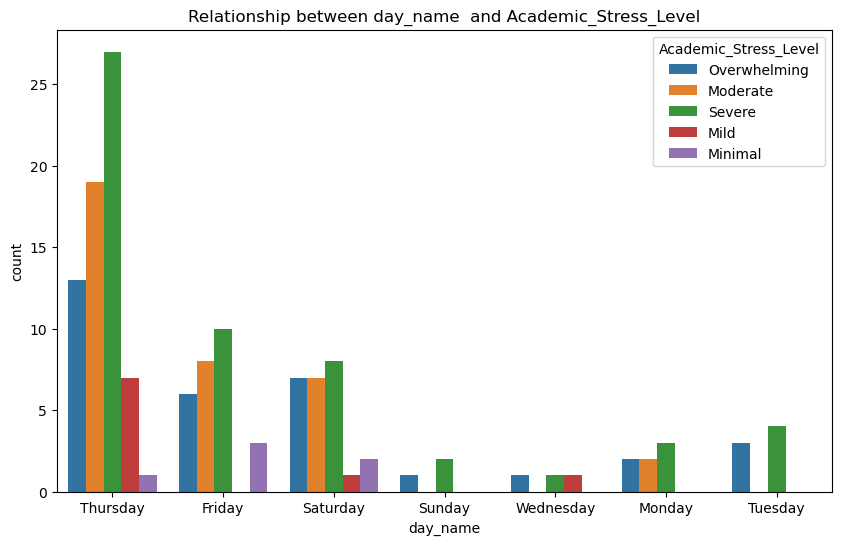

In [127]:
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='day_name', hue='Academic_Stress_Level')
plt.title('Relationship between day_name  and Academic_Stress_Level')
plt.show()

In [129]:
df1.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure home', 'Study Environment', 'Coping_Mechanism',
       'Lifestyle_Habits', 'Academic Competition', 'Academic_Stress_Level',
       'year', 'day_name', 'day', 'Month_Name'],
      dtype='object')

### "Did the average stress level distributed among students differ between July and August?

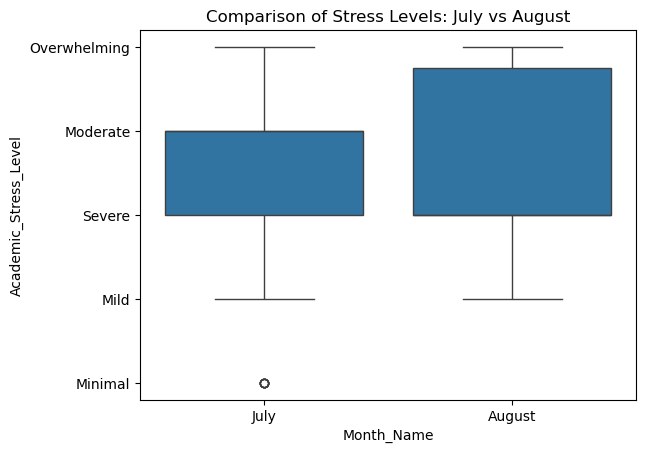

In [135]:
sns.boxplot(x='Month_Name', y='Academic_Stress_Level', data=df1[df1['Month_Name'].isin(['July', 'August'])])
plt.title('Comparison of Stress Levels: July vs August')
plt.show()

In [143]:
stress_map = {
    'Minimal': 1,
    'Mild': 2,
    'Moderate': 3,
    'Severe': 4,
    'Overwhelming': 5
}

df1['stress_score'] = df1['Academic_Stress_Level'].map(stress_map)



In [150]:
df1['stress_score']= df1['stress_score'].astype("int")

In [151]:
df1.sample()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure home,Study Environment,Coping_Mechanism,Lifestyle_Habits,Academic Competition,Academic_Stress_Level,year,day_name,day,Month_Name,stress_score
73,2025-07-25 10:43:24+00:00,undergraduate,Moderate,Moderate Pressure,disrupted,Problem Solving,No,High,Severe,2025,Friday,25,July,4


In [154]:
july_stress = df1[df1['Month_Name'] == 'July']['stress_score']
august_stress = df1[df1['Month_Name'] == 'August']['stress_score']

In [155]:
from scipy import stats
#  T-test
t_stat, p_value = stats.ttest_ind(july_stress, august_stress, nan_policy='omit')


print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -1.4820
P-value: 0.1406


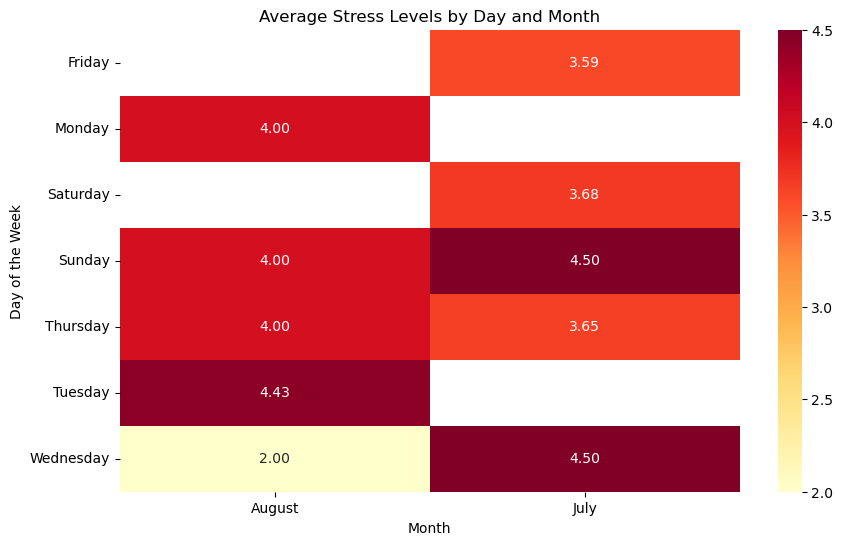

In [158]:
pivot_table = df1.pivot_table(index='day_name', 
                             columns='Month_Name', 
                             values='stress_score', 
                             aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt=".2f")

plt.title('Average Stress Levels by Day and Month')
plt.xlabel('Month')
plt.ylabel('Day of the Week')
plt.show()